
| Component | Description |
|-----------|-------------|
| **Input** | Earnings call transcript text (tokenized via FinBERT tokenizer) |
| **Target** | Post-earnings return (%) over a configurable window (1, 3, or 5 trading days) |

Data loading pipeline:
1. Load earnings call transcripts from Alpha Vantage, with local caching so repeated notebook runs do not use API calls.
2. Fetch post-earnings stock returns from Yahoo Finance.
3. Combine transcript text with `return_pct`, the 3-trading-day post-earnings return used as the model target.

This notebook imports the loader and dataset classes from the project package rather than redefining them in the notebook.


In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import sys
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()))

from dataset import TranscriptLoader, PriceLoader, EarningsDataset
from dataset import clean_transcript

print('Package imported')

Package imported


Example data loading without my API key so you can see it 

In [5]:
# Load the bundled example data points
examples_path = Path('notebooks/data/examples/example_transcripts.json')
if not examples_path.exists():
    examples_path = Path('data/examples/example_transcripts.json')
with open(examples_path) as f:
    examples = json.load(f)

print(f'Loaded {len(examples)} example transcripts')
print('\nFields in each record:')
for key in examples[0].keys():
    print(f'  {key}: {type(examples[0][key]).__name__}')

Loaded 3 example transcripts

Fields in each record:
  symbol: str
  quarter: str
  fiscalDateEnding: str
  earnings_date: str
  transcript: str
  return_pct: float
  price_day0: float
  price_dayN: float
  return_window: int
  direction: int


In [6]:
# Quick look at the examples as a DataFrame
df = pd.DataFrame([{
    'symbol': e['symbol'],
    'quarter': e['quarter'],
    'earnings_date': e['earnings_date'],
    'price_day0': e['price_day0'],
    'price_dayN': e['price_dayN'],
    'return_pct': e['return_pct'],
    'direction': e['direction'],
    'return_window': e['return_window'],
    'transcript_words': len(e['transcript'].split()),
} for e in examples])

df

,symbol,quarter,earnings_date,price_day0,price_dayN,return_pct,direction,return_window,transcript_words
0,AAPL,2024Q1,2024-02-01,185.85,184.18,-0.89,0,3,177
1,MSFT,2024Q2,2024-01-30,404.87,415.97,2.74,1,3,122
2,META,2024Q1,2024-04-24,493.50,441.38,-10.56,0,3,139


- `return_pct` is the target variable — what the model will predict
- `direction` is a derived binary label (1 = stock went up, 0 = down)
- Transcripts are ~150–200 words in the examples; real full transcripts are 5,000–15,000 words
- Returns vary a lot: META dropped 10.5% despite strong revenue — driven by capex guidance language

Getting my transcript with API key 

In [ ]:
# Uncomment and run if you have an API key in your .env file
# loader = TranscriptLoader()
# transcript_data = loader.load('AAPL', '2024Q1')
# print(f"Symbol: {transcript_data['symbol']}")
# print(f"Quarter: {transcript_data['quarter']}")
# print(f"Speaker turns: {len(transcript_data['transcript'])}")
# print(transcript_data['transcript'][0]['content'][:500])


After the first API call, the transcript is saved to data/transcripts/AAPL_2024Q1.json. Every call then reads from disk — no API hit. That way we aren't re-hitting the API on every batch run.

In [9]:
# Use yahoo finance to pull return data 
price_loader = PriceLoader(return_window=3)

result = price_loader.get_return('AAPL', '2024-02-01')
print('Return data for AAPL Q1 2024 earnings:')
for k, v in result.items():
    print(f'  {k}: {v}')

Return data for AAPL Q1 2024 earnings:
  symbol: AAPL
  earnings_date: 2024-02-01
  return_window: 3
  price_day0: 184.7685
  price_dayN: 187.1812
  return_pct: 1.3058
  direction: 1


In [11]:
# retruns for all example tickers
pairs = [(e['symbol'], e['earnings_date']) for e in examples]
returns_df = price_loader.get_returns_batch(pairs)
print('Batch returns:')
returns_df

Batch returns:


,symbol,earnings_date,return_window,price_day0,price_dayN,return_pct,direction
0,AAPL,2024-02-01,3,184.7685,187.1812,1.3058,1
1,MSFT,2024-01-30,3,400.8026,403.3825,0.6437,1
2,META,2024-04-24,3,490.1769,429.7069,-12.3364,0


Chose 3 days for this project, but future experiments could compare `PriceLoader(return_window=N)` with 1-day or 5-day returns.

preproccess text

In [12]:
from dataset import clean_transcript

raw = examples[0]['transcript']
cleaned = clean_transcript(raw)

print(f'Raw length:    {len(raw)} chars')
print(f'Cleaned length: {len(cleaned)} chars')
print(f'\nCleaned preview:')
print(cleaned[:400])

Raw length:    1062 chars
Cleaned length: 1062 chars

Cleaned preview:
Good afternoon, everyone. Thank you for joining Apple's first quarter fiscal 2024 earnings conference call. I'm Suhasini Chandramouli, Director of Investor Relations, and with me today is Tim Cook, Apple's CEO, and Luca Maestri, Apple's CFO. We are providing a presentation today that is available on our website with more detail than usual. As a reminder, a replay of today's call will be available 


Build the dataset from our example records

In [13]:
# In real training, 'examples' would be thousands of transcript+return dicts

dataset = EarningsDataset(examples, max_length=128)  # 128 for demo speed; use 512 for training
print(f'Dataset size: {len(dataset)} samples')

Dataset size: 3 samples


In [14]:
# Inspect a single sample — this is exactly what the model will receive
sample = dataset[0]

print('=== MODEL INPUTS ===')
print(f'input_ids shape:      {sample["input_ids"].shape}   (one token ID per position)')
print(f'attention_mask shape: {sample["attention_mask"].shape}   (1=real token, 0=padding)')
print(f'\ninput_ids (first 20 tokens): {sample["input_ids"][:20]}')

print('\n=== MODEL TARGET ===')
print(f'return_pct (label):   {sample["label"]:.4f}%')

print('\n=== METADATA ===')
print(f'symbol:               {sample["symbol"]}')
print(f'quarter:              {sample["quarter"]}')
print(f'earnings_date:        {sample["earnings_date"]}')

=== MODEL INPUTS ===
input_ids shape:      torch.Size([128])   (one token ID per position)
attention_mask shape: torch.Size([128])   (1=real token, 0=padding)

input_ids (first 20 tokens): tensor([  101,  2204,  5027,  1010,  3071,  1012,  4067,  2017,  2005,  5241,
         6207,  1005,  1055,  2034,  4284, 10807, 16798,  2549, 16565,  3034])

=== MODEL TARGET ===
return_pct (label):   -0.8900%

=== METADATA ===
symbol:               AAPL
quarter:              2024Q1
earnings_date:        2024-02-01


Target Variable Distribution

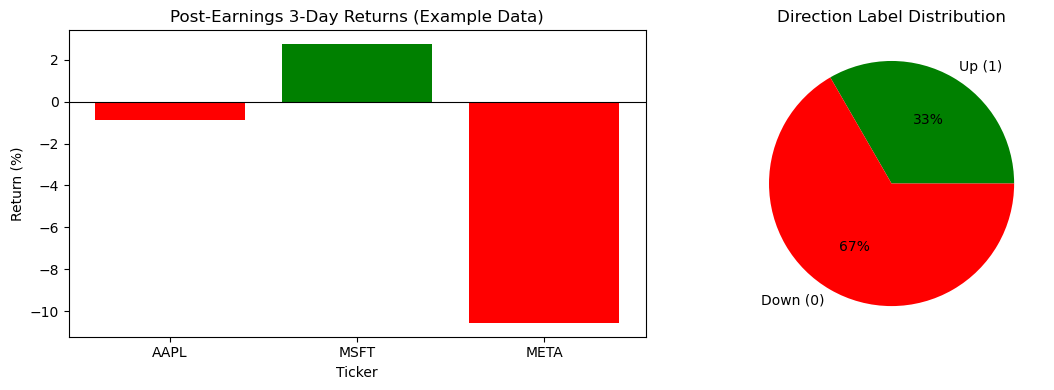

Mean return: -2.90%
Std return:  6.87%


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Return distribution
returns = [e['return_pct'] for e in examples]
axes[0].bar([e['symbol'] for e in examples], returns, color=['red' if r < 0 else 'green' for r in returns])
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Post-Earnings 3-Day Returns (Example Data)')
axes[0].set_ylabel('Return (%)')
axes[0].set_xlabel('Ticker')

# Direction breakdown
directions = [e['direction'] for e in examples]
axes[1].pie(
    [sum(directions), len(directions) - sum(directions)],
    labels=['Up (1)', 'Down (0)'],
    colors=['green', 'red'],
    autopct='%1.0f%%',
)
axes[1].set_title('Direction Label Distribution')

plt.tight_layout()
plt.show()

print(f'Mean return: {pd.Series(returns).mean():.2f}%')
print(f'Std return:  {pd.Series(returns).std():.2f}%')